In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/ecommerce/ECommerce.csv')

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()

Shape: (5630, 20)

Column names:
['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']

Data types:
CustomerID                       int64
Churn                            int64
Tenure                         float64
PreferredLoginDevice               str
CityTier                         int64
WarehouseToHome                float64
PreferredPaymentMode               str
Gender                             str
HourSpendOnApp                 float64
NumberOfDeviceRegistered         int64
PreferedOrderCat                   str
SatisfactionScore                int64
MaritalStatus                      str
NumberOfAddress                  int64
Complain                         int64
OrderAmountHi

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [3]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

print("\nBasic statistics:")
df.describe().round(2)

Missing values per column:
                             Missing Count  Missing %
DaySinceLastOrder                      307       5.45
OrderAmountHikeFromlastYear            265       4.71
Tenure                                 264       4.69
OrderCount                             258       4.58
CouponUsed                             256       4.55
HourSpendOnApp                         255       4.53
WarehouseToHome                        251       4.46

Basic statistics:


,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.00,5630.00,5366.00,5630.00,5379.00,5375.00,5630.00,5630.00,5630.00,5630.00,5365.00,5374.00,5372.00,5323.00,5630.00
mean,52815.50,0.17,10.19,1.65,15.64,2.93,3.69,3.07,4.21,0.28,15.71,1.75,3.01,4.54,177.22
std,1625.39,0.37,8.56,0.92,8.53,0.72,1.02,1.38,2.58,0.45,3.68,1.89,2.94,3.65,49.19
min,50001.00,0.00,0.00,1.00,5.00,0.00,1.00,1.00,1.00,0.00,11.00,0.00,1.00,0.00,0.00
25%,51408.25,0.00,2.00,1.00,9.00,2.00,3.00,2.00,2.00,0.00,13.00,1.00,1.00,2.00,146.00
50%,52815.50,0.00,9.00,1.00,14.00,3.00,4.00,3.00,3.00,0.00,15.00,1.00,2.00,3.00,163.00
75%,54222.75,0.00,16.00,3.00,20.00,3.00,4.00,4.00,6.00,1.00,18.00,2.00,3.00,7.00,196.00
max,55630.00,1.00,61.00,3.00,127.00,5.00,6.00,5.00,22.00,1.00,26.00,16.00,16.00,46.00,325.00


Churn distribution:
Churn
0    4682
1     948
Name: count, dtype: int64

Churn rate : 16.8%
Retention  : 83.2%


C:\Users\DELL\AppData\Local\Temp\ipykernel_24952\3311053928.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df,


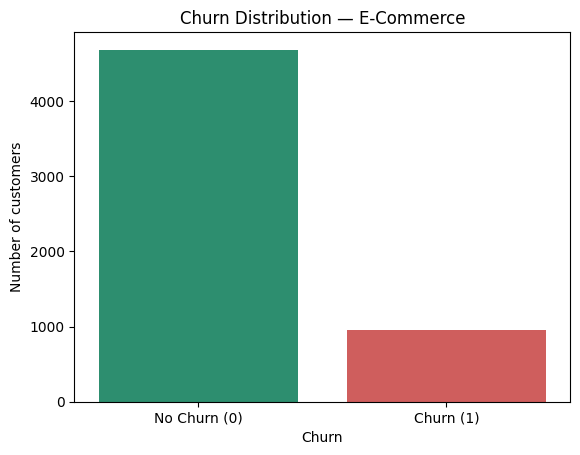


Research note:
Telecom churn was ~26.5%.
E-commerce churn is 16.8%.
Document the difference — this affects SMOTE strategy.


In [4]:
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:")
print(churn_counts)
print(f"\nChurn rate : {churn_pct[1]:.1f}%")
print(f"Retention  : {churn_pct[0]:.1f}%")

sns.countplot(x='Churn', data=df,
              palette=['#1D9E75','#E24B4A'])
plt.title('Churn Distribution — E-Commerce')
plt.xticks([0,1], ['No Churn (0)','Churn (1)'])
plt.ylabel('Number of customers')
plt.savefig('outputs/plots/ecommerce/01_churn_dist.png',
            bbox_inches='tight')
plt.show()

print("\nResearch note:")
print(f"Telecom churn was ~26.5%.")
print(f"E-commerce churn is {churn_pct[1]:.1f}%.")
print("Document the difference — this affects SMOTE strategy.")

Numerical columns found: ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']


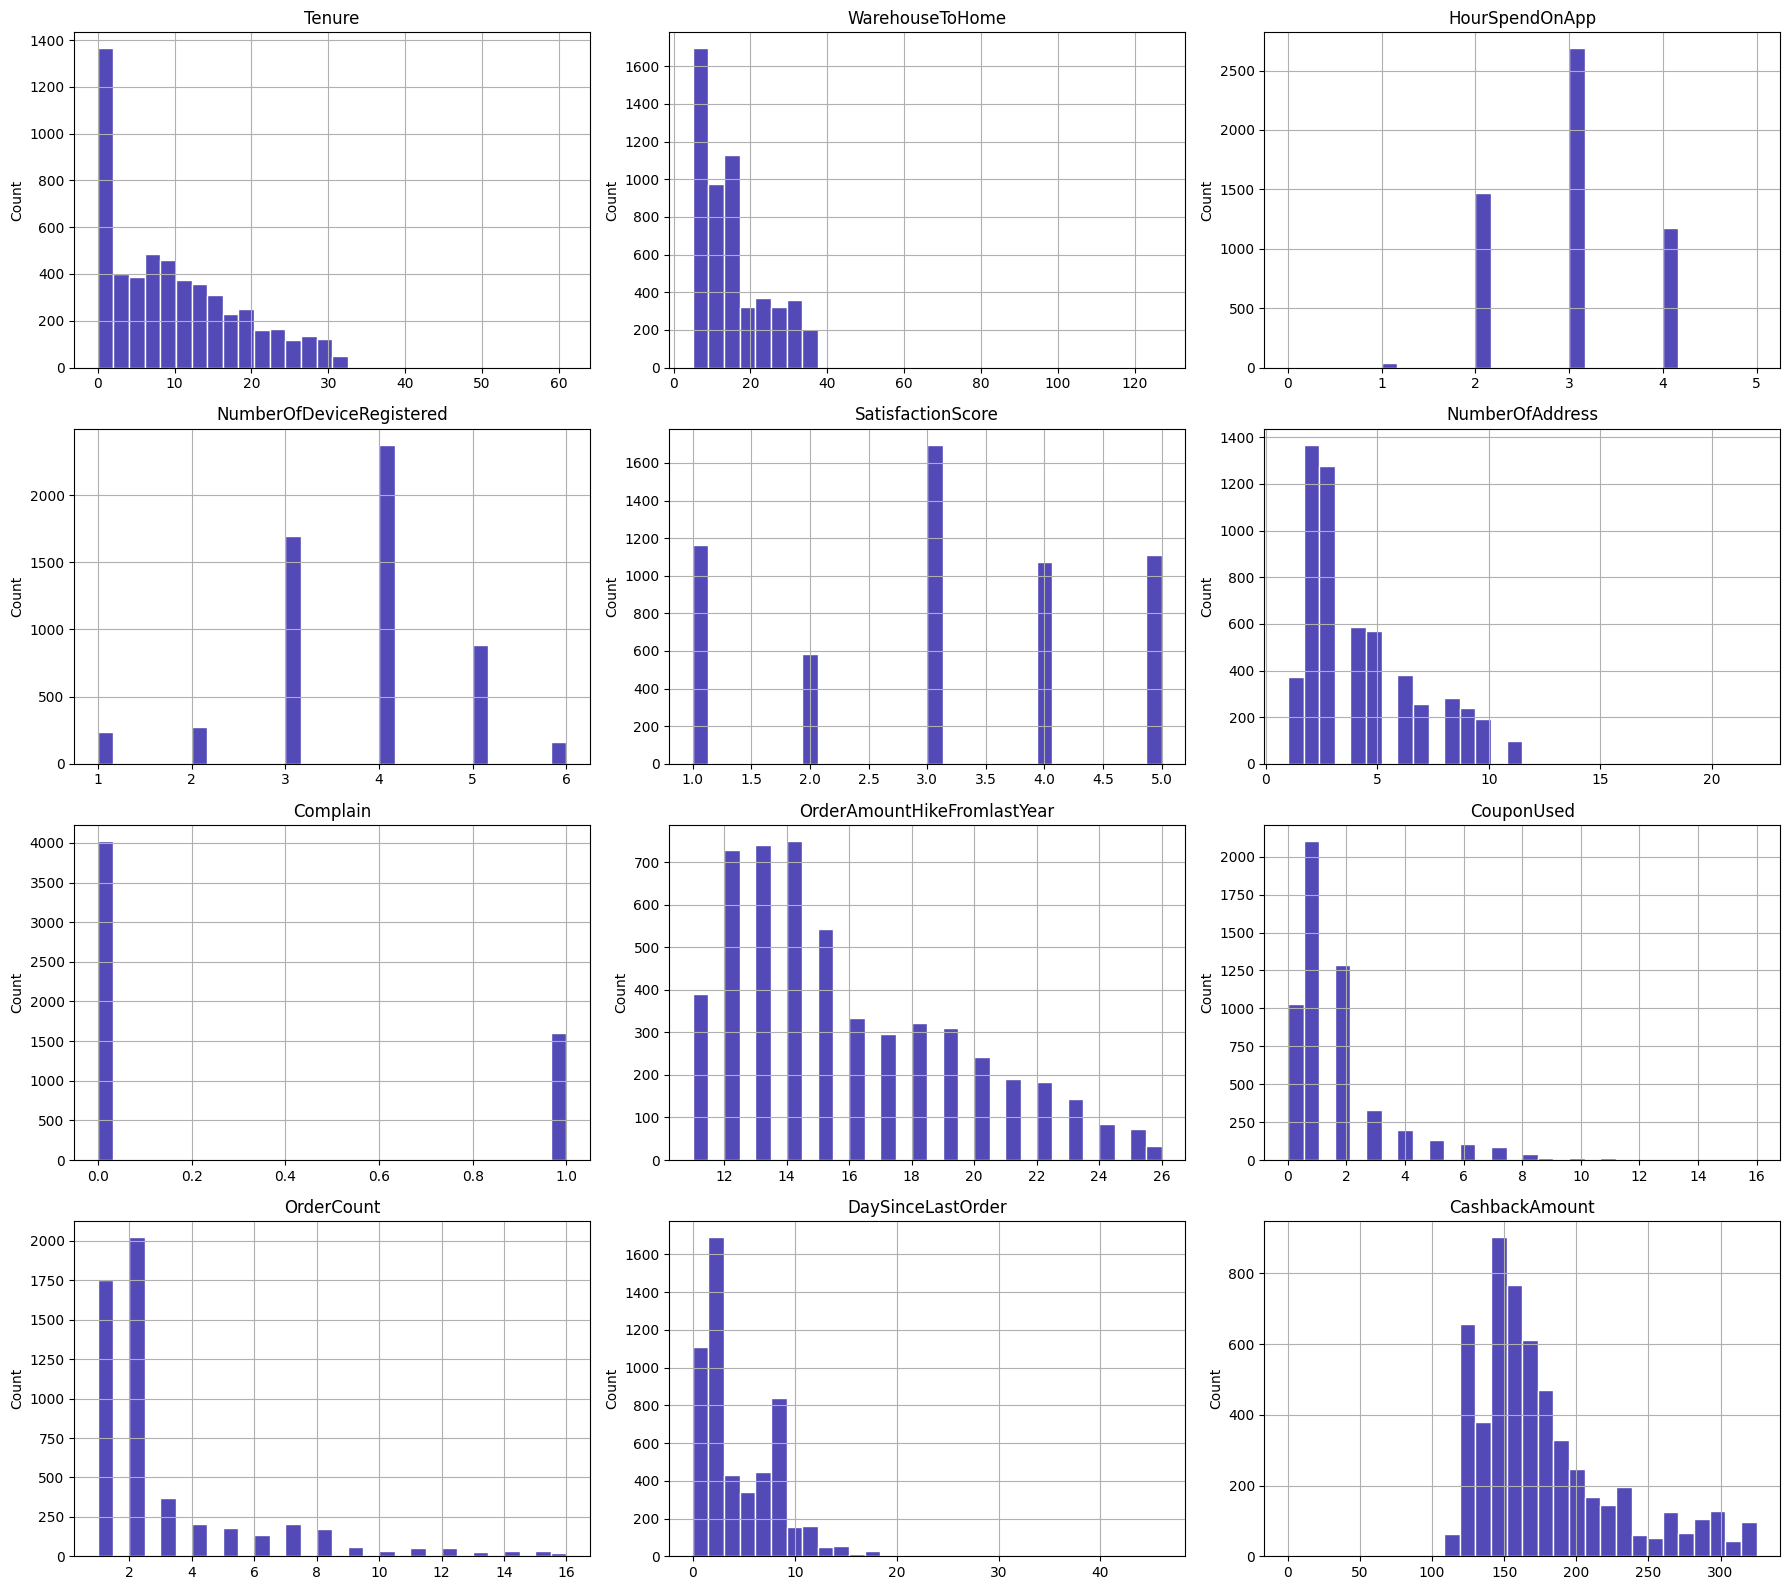


Descriptive stats:
        Tenure  WarehouseToHome  HourSpendOnApp  NumberOfDeviceRegistered  \
count  5366.00          5379.00         5375.00                   5630.00   
mean     10.19            15.64            2.93                      3.69   
std       8.56             8.53            0.72                      1.02   
min       0.00             5.00            0.00                      1.00   
25%       2.00             9.00            2.00                      3.00   
50%       9.00            14.00            3.00                      4.00   
75%      16.00            20.00            3.00                      4.00   
max      61.00           127.00            5.00                      6.00   

       SatisfactionScore  NumberOfAddress  Complain  \
count            5630.00          5630.00   5630.00   
mean                3.07             4.21      0.28   
std                 1.38             2.58      0.45   
min                 1.00             1.00      0.00   
25%        

In [5]:
import os
os.makedirs('outputs/plots/ecommerce', exist_ok=True)

# Key numerical columns in E-commerce dataset
num_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp',
    'NumberOfDeviceRegistered', 'SatisfactionScore',
    'NumberOfAddress', 'Complain',
    'OrderAmountHikeFromlastYear', 'CouponUsed',
    'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'
]

# Filter to only existing columns
num_cols = [c for c in num_cols if c in df.columns]
print("Numerical columns found:", num_cols)

fig, axes = plt.subplots(
    (len(num_cols)+2)//3, 3,
    figsize=(18, 4 * ((len(num_cols)+2)//3))
)
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(bins=30, ax=axes[i],
                 color='#534AB7', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/02_numerical_dists.png',
            bbox_inches='tight')
plt.show()

print("\nDescriptive stats:")
print(df[num_cols].describe().round(2))

Categorical columns found: ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


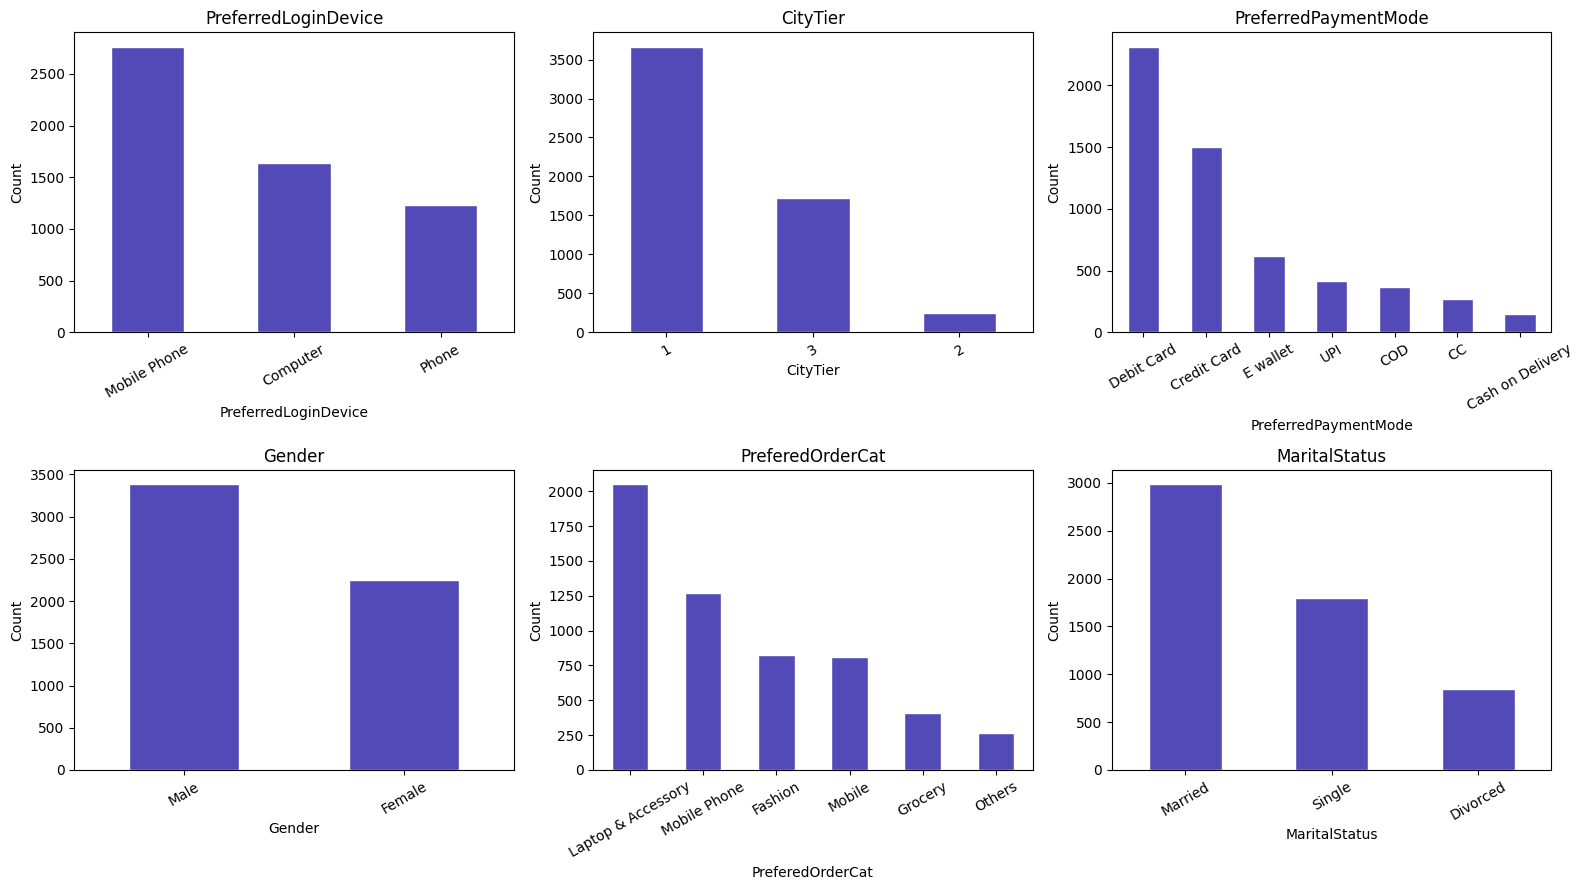

In [6]:
# Key categorical columns
cat_cols = [
    'PreferredLoginDevice', 'CityTier',
    'PreferredPaymentMode', 'Gender',
    'PreferedOrderCat', 'MaritalStatus'
]
cat_cols = [c for c in cat_cols if c in df.columns]
print("Categorical columns found:", cat_cols)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
        kind='bar', ax=axes[i],
        color='#534AB7', edgecolor='white'
    )
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/03_categorical_dists.png',
            bbox_inches='tight')
plt.show()

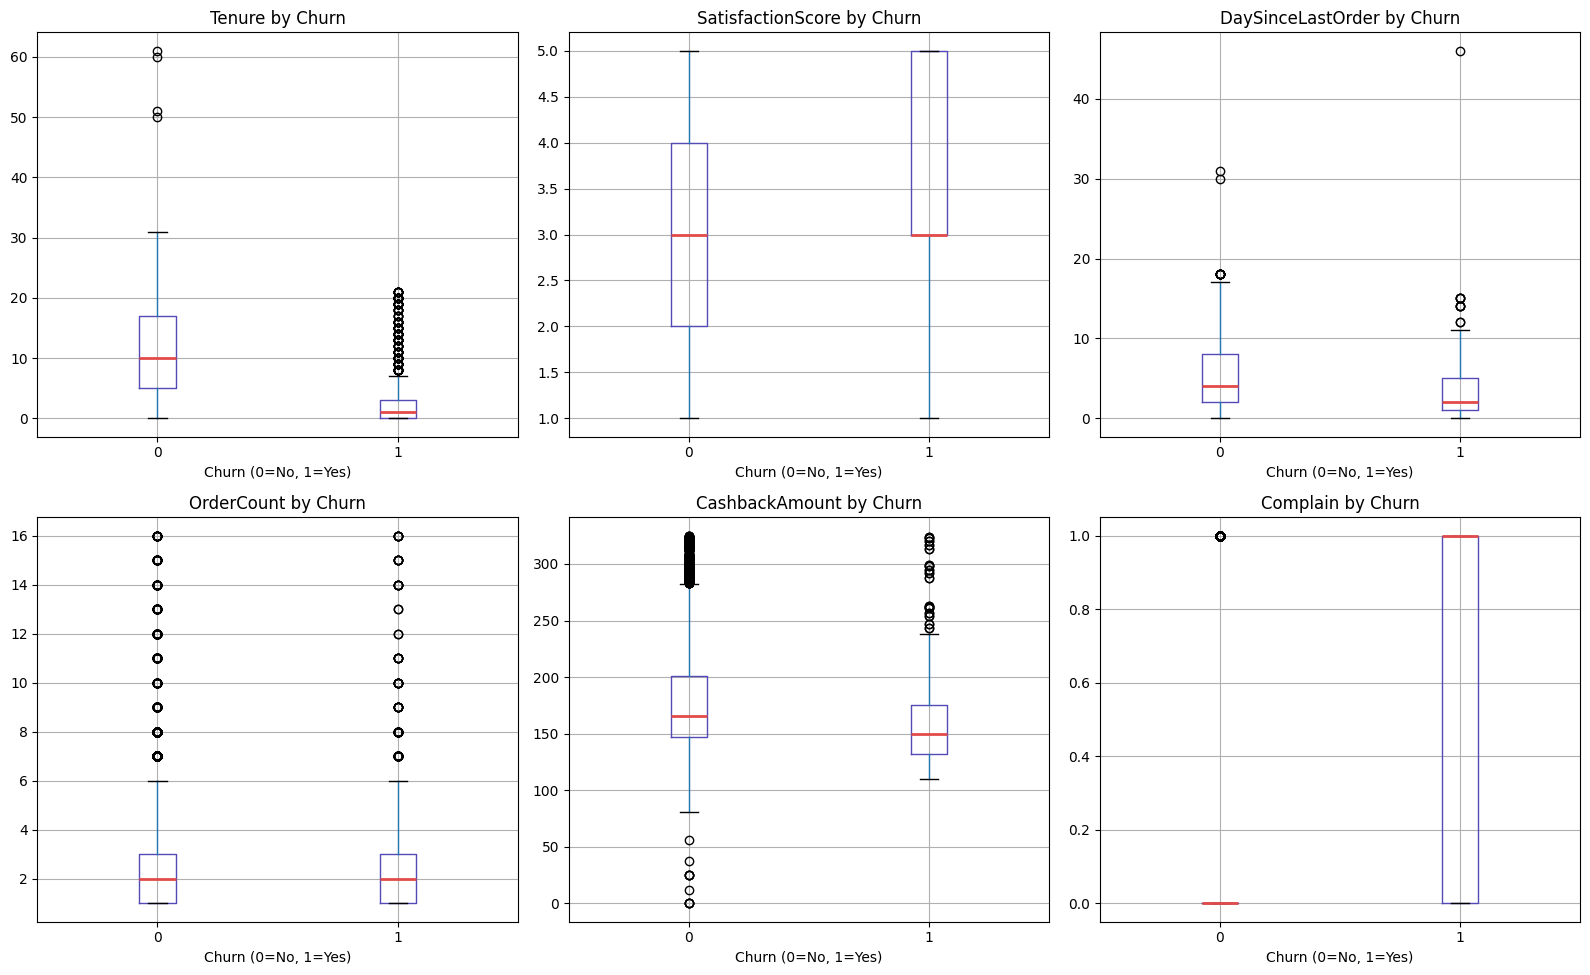


Mean values by Churn group:
       Tenure  SatisfactionScore  DaySinceLastOrder  OrderCount  \
Churn                                                             
0       11.50               3.00               4.81        3.05   
1        3.38               3.39               3.24        2.82   

       CashbackAmount  Complain  
Churn                            
0              180.63      0.23  
1              160.37      0.54  


In [7]:
key_num = [
    'Tenure', 'SatisfactionScore',
    'DaySinceLastOrder', 'OrderCount',
    'CashbackAmount', 'Complain'
]
key_num = [c for c in key_num if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_num):
    df.boxplot(column=col, by='Churn', ax=axes[i],
               boxprops=dict(color='#534AB7'),
               medianprops=dict(color='#E24B4A', linewidth=2))
    axes[i].set_title(f'{col} by Churn')
    axes[i].set_xlabel('Churn (0=No, 1=Yes)')

plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/04_num_vs_churn.png',
            bbox_inches='tight')
plt.show()

print("\nMean values by Churn group:")
print(df.groupby('Churn')[key_num].mean().round(2))

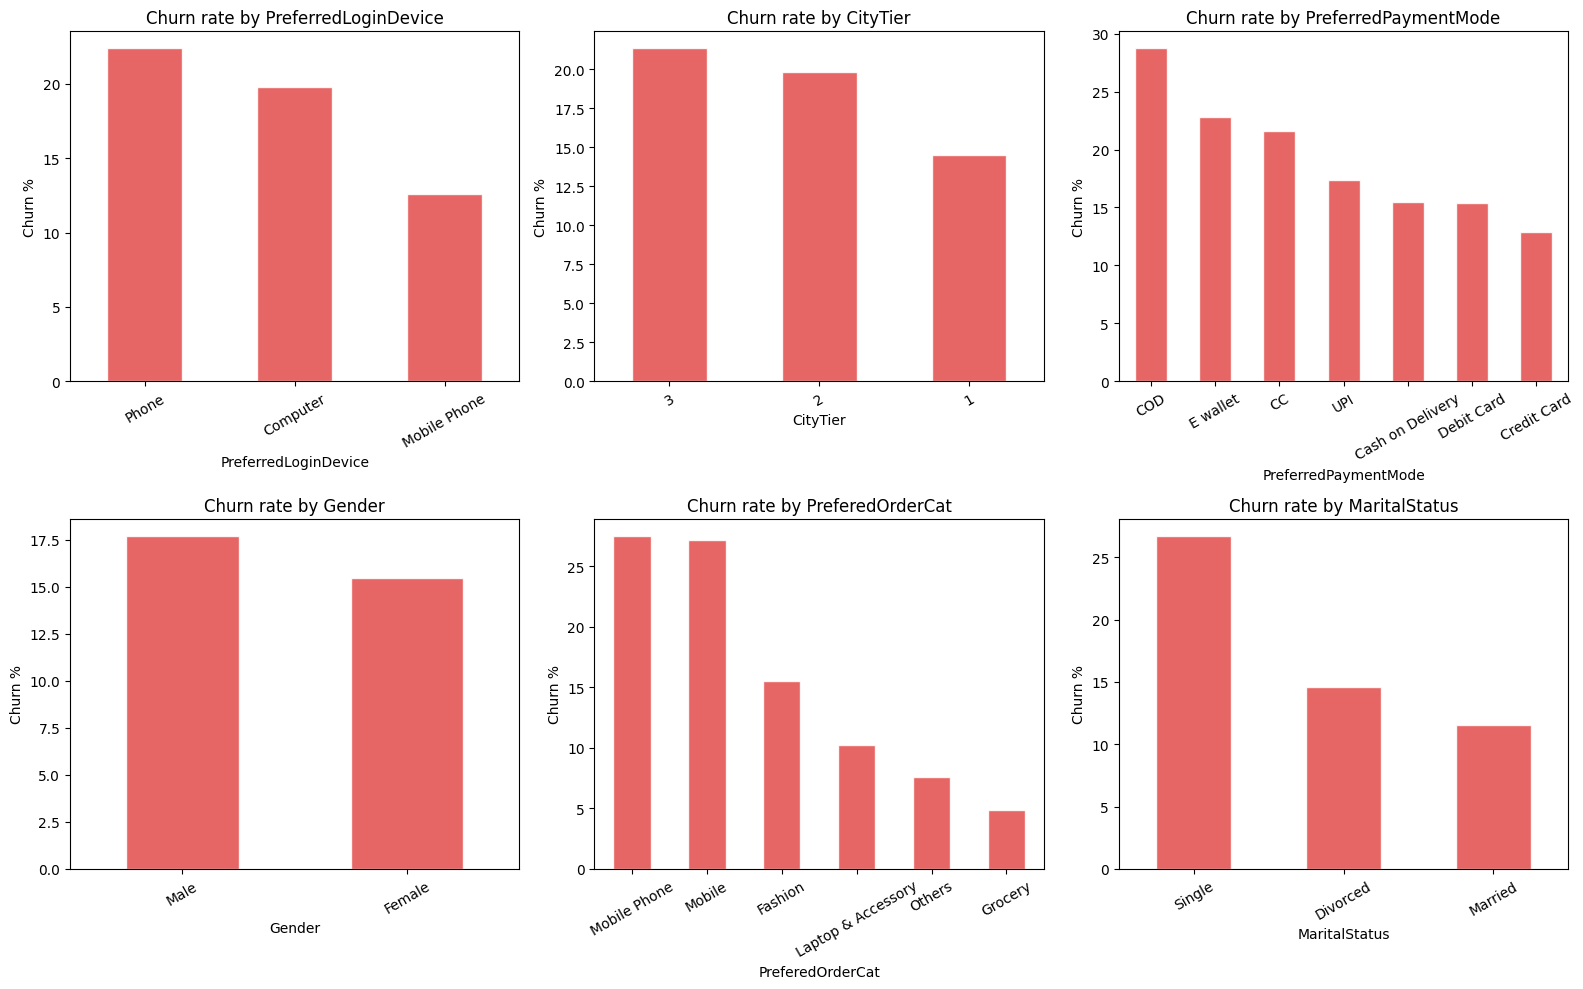


Churn rate per category:

PreferredLoginDevice:
PreferredLoginDevice
Computer        19.8
Mobile Phone    12.6
Phone           22.4
Name: Churn, dtype: float64

CityTier:
CityTier
1    14.5
2    19.8
3    21.4
Name: Churn, dtype: float64

PreferredPaymentMode:
PreferredPaymentMode
CC                  21.6
COD                 28.8
Cash on Delivery    15.4
Credit Card         12.9
Debit Card          15.4
E wallet            22.8
UPI                 17.4
Name: Churn, dtype: float64

Gender:
Gender
Female    15.5
Male      17.7
Name: Churn, dtype: float64

PreferedOrderCat:
PreferedOrderCat
Fashion               15.5
Grocery                4.9
Laptop & Accessory    10.2
Mobile                27.2
Mobile Phone          27.5
Others                 7.6
Name: Churn, dtype: float64

MaritalStatus:
MaritalStatus
Divorced    14.6
Married     11.5
Single      26.7
Name: Churn, dtype: float64


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.sort_values(ascending=False).plot(
        kind='bar', ax=axes[i],
        color='#E24B4A', edgecolor='white', alpha=0.85
    )
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn %')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/05_cat_vs_churn.png',
            bbox_inches='tight')
plt.show()

print("\nChurn rate per category:")
for col in cat_cols:
    print(f"\n{col}:")
    print((df.groupby(col)['Churn'].mean()*100).round(1))

C:\Users\DELL\AppData\Local\Temp\ipykernel_24952\3596358935.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes('object').columns:


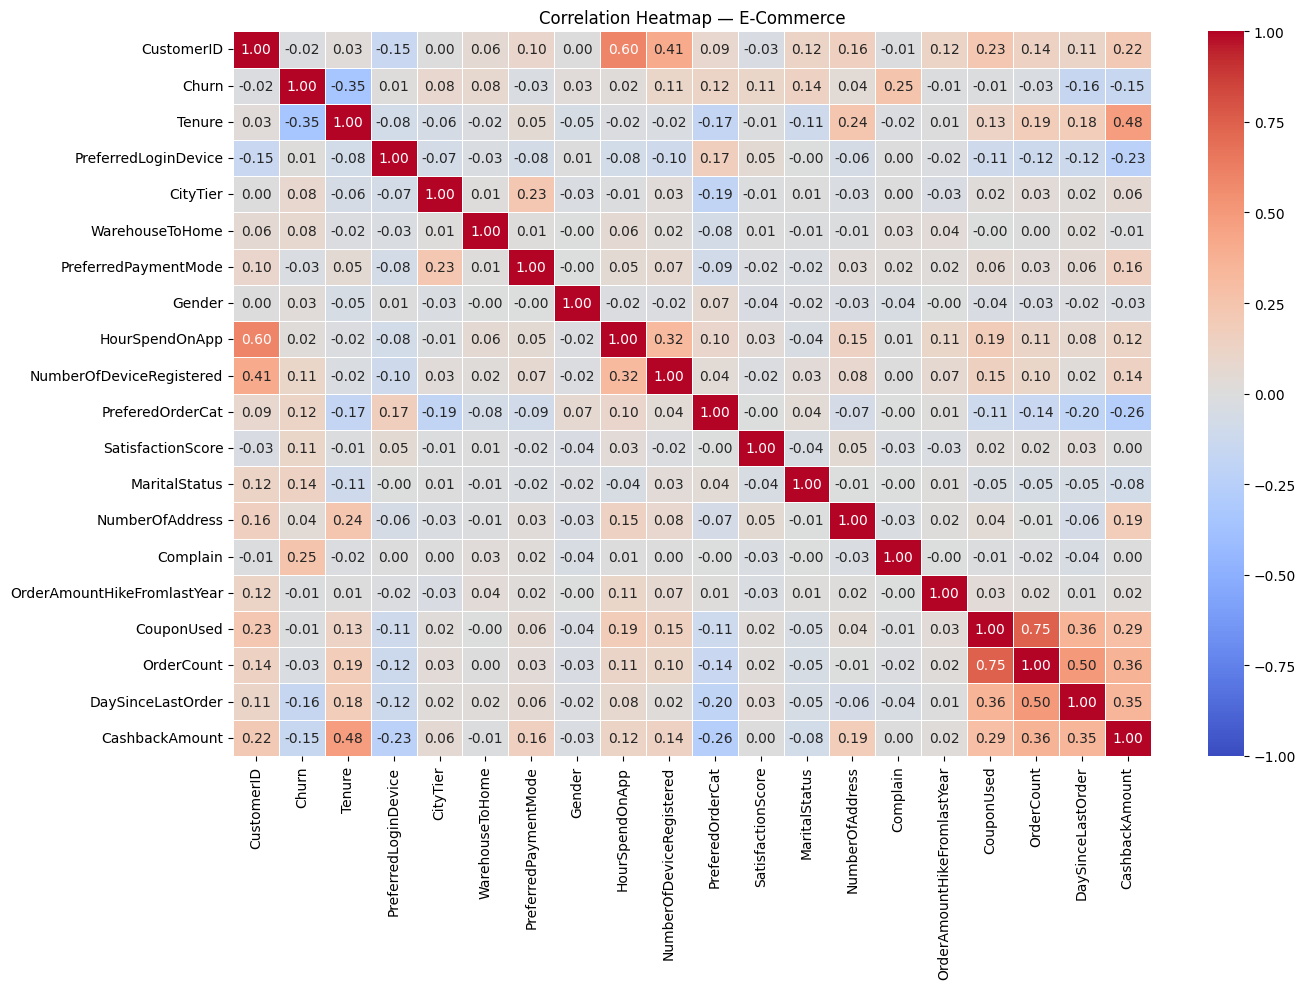


Correlation with Churn (sorted):
Tenure                        -0.349
Complain                       0.250
DaySinceLastOrder             -0.161
CashbackAmount                -0.154
MaritalStatus                  0.140
PreferedOrderCat               0.119
NumberOfDeviceRegistered       0.108
SatisfactionScore              0.105
CityTier                       0.085
WarehouseToHome                0.077
NumberOfAddress                0.044
Gender                         0.029
OrderCount                    -0.029
PreferredPaymentMode          -0.027
CustomerID                    -0.019
HourSpendOnApp                 0.019
PreferredLoginDevice           0.013
OrderAmountHikeFromlastYear   -0.010
CouponUsed                    -0.008
Name: Churn, dtype: float64


In [9]:
df_encoded = df.copy()

for col in df_encoded.select_dtypes('object').columns:
    from sklearn.preprocessing import LabelEncoder
    df_encoded[col] = LabelEncoder().fit_transform(
        df_encoded[col].astype(str)
    )

numeric_df = df_encoded.select_dtypes(include='number')

plt.figure(figsize=(14, 10))
sns.heatmap(
    numeric_df.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    center=0, vmin=-1, vmax=1
)
plt.title('Correlation Heatmap — E-Commerce')
plt.tight_layout()
plt.savefig('outputs/plots/ecommerce/06_heatmap.png',
            bbox_inches='tight')
plt.show()

print("\nCorrelation with Churn (sorted):")
print(
    numeric_df.corr()['Churn']
    .drop('Churn')
    .sort_values(key=abs, ascending=False)
    .round(3)
)